In [1]:
#from ema_workbench import load_results

#experiments, outcomes = load_results('ema_resultsprobstate3.tar.gz')

In [2]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from openpyxl.styles.builtins import output
from ema_workbench import (
    Model,
    Policy,
    ema_logging,
    SequentialEvaluator,
    MultiprocessingEvaluator,
)
from dike_model_function import DikeNetwork  # @UnresolvedImport
from problem_formulation import get_model_for_problem_formulation, sum_over, sum_over_time

In [3]:
ema_logging.log_to_stderr(ema_logging.INFO)

# choose problem formulation number, between 0-5
# each problem formulation has its own list of outcomes
dike_model, planning_steps = get_model_for_problem_formulation(3)

In [4]:
# enlisting uncertainties, their types (RealParameter/IntegerParameter/CategoricalParameter), lower boundary, and upper boundary
import copy

for unc in dike_model.uncertainties:
    print(repr(unc))

uncertainties = copy.deepcopy(dike_model.uncertainties)

CategoricalParameter('discount rate 0', [0, 1, 2, 3])
CategoricalParameter('discount rate 1', [0, 1, 2, 3])
CategoricalParameter('discount rate 2', [0, 1, 2, 3])
IntegerParameter('A.0_ID flood wave shape', 0, 132, resolution=None, default=None, variable_name=['A.0_ID flood wave shape'], pff=False)
RealParameter('A.1_Bmax', 30, 350, resolution=None, default=None, variable_name=['A.1_Bmax'], pff=False)
RealParameter('A.1_pfail', 0, 1, resolution=None, default=None, variable_name=['A.1_pfail'], pff=False)
CategoricalParameter('A.1_Brate', [0, 1, 2])
RealParameter('A.2_Bmax', 30, 350, resolution=None, default=None, variable_name=['A.2_Bmax'], pff=False)
RealParameter('A.2_pfail', 0, 1, resolution=None, default=None, variable_name=['A.2_pfail'], pff=False)
CategoricalParameter('A.2_Brate', [0, 1, 2])
RealParameter('A.3_Bmax', 30, 350, resolution=None, default=None, variable_name=['A.3_Bmax'], pff=False)
RealParameter('A.3_pfail', 0, 1, resolution=None, default=None, variable_name=['A.3_pfai

In [5]:
# enlisting policy levers, their types (RealParameter/IntegerParameter), lower boundary, and upper boundary
for policy in dike_model.levers:
    print(repr(policy))

levers = copy.deepcopy(dike_model.levers)

IntegerParameter('0_RfR 0', 0, 1, resolution=None, default=None, variable_name=['0_RfR 0'], pff=False)
IntegerParameter('0_RfR 1', 0, 1, resolution=None, default=None, variable_name=['0_RfR 1'], pff=False)
IntegerParameter('0_RfR 2', 0, 1, resolution=None, default=None, variable_name=['0_RfR 2'], pff=False)
IntegerParameter('1_RfR 0', 0, 1, resolution=None, default=None, variable_name=['1_RfR 0'], pff=False)
IntegerParameter('1_RfR 1', 0, 1, resolution=None, default=None, variable_name=['1_RfR 1'], pff=False)
IntegerParameter('1_RfR 2', 0, 1, resolution=None, default=None, variable_name=['1_RfR 2'], pff=False)
IntegerParameter('2_RfR 0', 0, 1, resolution=None, default=None, variable_name=['2_RfR 0'], pff=False)
IntegerParameter('2_RfR 1', 0, 1, resolution=None, default=None, variable_name=['2_RfR 1'], pff=False)
IntegerParameter('2_RfR 2', 0, 1, resolution=None, default=None, variable_name=['2_RfR 2'], pff=False)
IntegerParameter('3_RfR 0', 0, 1, resolution=None, default=None, variable

In [6]:
# enlisting outcomes
for outcome in dike_model.outcomes:
    print(repr(outcome))

ScalarOutcome('A.1 Total Costs', variable_name=('A.1_Expected Annual Damage', 'A.1_Dike Investment Costs'), function=<function sum_over at 0x123fc54e0>)
ScalarOutcome('A.1_Expected Number of Deaths', variable_name=('A.1_Expected Number of Deaths',), function=<function sum_over at 0x123fc54e0>)
ScalarOutcome('A.2 Total Costs', variable_name=('A.2_Expected Annual Damage', 'A.2_Dike Investment Costs'), function=<function sum_over at 0x123fc54e0>)
ScalarOutcome('A.2_Expected Number of Deaths', variable_name=('A.2_Expected Number of Deaths',), function=<function sum_over at 0x123fc54e0>)
ScalarOutcome('A.3 Total Costs', variable_name=('A.3_Expected Annual Damage', 'A.3_Dike Investment Costs'), function=<function sum_over at 0x123fc54e0>)
ScalarOutcome('A.3_Expected Number of Deaths', variable_name=('A.3_Expected Number of Deaths',), function=<function sum_over at 0x123fc54e0>)
ScalarOutcome('A.4 Total Costs', variable_name=('A.4_Expected Annual Damage', 'A.4_Dike Investment Costs'), functio

In [7]:
# running the model through EMA workbench
with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.perform_experiments(scenarios=100, policies=1)

[MainProcess/INFO] pool started with 8 workers
[MainProcess/INFO] performing 100 scenarios * 1 policies * 1 model(s) = 100 experiments
100%|████████████████████████████████████████| 100/100 [00:02<00:00, 35.62it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] terminating pool


In [8]:
experiments, outcomes = results

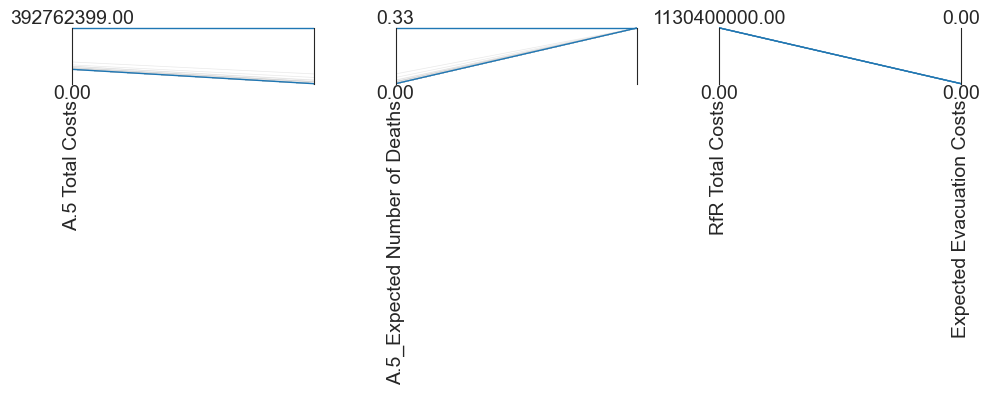

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ema_workbench.analysis import parcoords

# Combine all outcomes into a single DataFrame
all_data = pd.DataFrame({k: v for k, v in outcomes.items()})

# Focus only on selected outcomes
selected_outcomes = [
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths',
    'RfR Total Costs',
    'Expected Evacuation Costs'
]
all_data = all_data[selected_outcomes]

# Get indices of rows with min and max values across outcomes
indices = pd.concat([all_data.idxmax(), all_data.idxmin()]).unique()

# Create axis limits and force min to 0
limits = parcoords.get_limits(all_data)
limits.loc[0, selected_outcomes] = 0

# Initialize parallel coordinates plot
axes = parcoords.ParallelAxes(limits)

# Plot all lines in grey with transparency
axes.plot(all_data, color='lightgrey', lw=0.5, alpha=0.5)

# Highlight rows with extreme values
axes.plot(all_data.loc[indices], color=sns.color_palette()[0], lw=1)

# Final layout
fig = plt.gcf()
fig.set_size_inches((10, 4))  # wider if needed
plt.tight_layout()
plt.show()


In [10]:
print(all_data.idxmax())
print(all_data.idxmin())

A.5 Total Costs                  30
A.5_Expected Number of Deaths    30
RfR Total Costs                   0
Expected Evacuation Costs         0
dtype: int64
A.5 Total Costs                  0
A.5_Expected Number of Deaths    0
RfR Total Costs                  0
Expected Evacuation Costs        0
dtype: int64


In [20]:
# also all we need are the uncertainty columns
#worst case scenario
selected = experiments.loc[[30, 0], ['A.1_Brate',
'A.2_Bmax',
'A.2_pfail',
'A.2_Brate',
'A.3_Bmax',
'A.3_pfail',
'A.3_Brate',
'A.4_Bmax',
'A.4_pfail',
'A.4_Brate',
'A.5_Bmax',
'A.5_pfail',
'A.5_Brate']]
selected

,A.1_Brate,A.2_Bmax,A.2_pfail,A.2_Brate,A.3_Bmax,A.3_pfail,A.3_Brate,A.4_Bmax,A.4_pfail,A.4_Brate,A.5_Bmax,A.5_pfail,A.5_Brate
30,1.0,83.148680,0.780138,1.5,272.249538,0.231267,1.5,285.441265,0.884394,1.5,204.458474,0.000391,1.5
0,1.5,278.529113,0.329584,1.0,323.490910,0.161151,1.0,218.217079,0.198499,10.0,163.682483,0.758931,1.5


In [21]:
#toevoegen aan lijst van scenarios
from ema_workbench import Scenario

scenarios = [Scenario(f"{index}", **row) for index, row in selected.iterrows()]

In [13]:
from sklearn import preprocessing
y = outcomes['A.5_Expected Number of Deaths'] < 0.000000001

experiments_of_interest = experiments.loc[y]
outcomes_df = pd.DataFrame({k:v[y] for k,v in outcomes.items()})

# normalize outcomes on unit interval to ensure equal weighting of outcomes
x = outcomes_df.values
min_max_scaler = preprocessing.MinMaxScaler()
x_scaled = min_max_scaler.fit_transform(x)
normalized_outcomes = pd.DataFrame(x_scaled, columns=outcomes_df.columns)

In [14]:
import itertools

n_scen = experiments.loc[y].shape[0]
indices = range(n_scen)
set_size = 4
n_scen
combinations = itertools.combinations(indices, set_size)
combinations = list(combinations)

In [15]:
print(len(combinations))

1837620


In [16]:
import random

sampled_combinations = random.sample(combinations, 100000)

In [17]:
from concurrent.futures import ProcessPoolExecutor
import os
import functools
from scipy.spatial.distance import pdist, squareform

# the relevant code is in a .py file to esnure parallization works within the notebook
from assignment_10_scenario_selection import find_maxdiverse_scenarios

# calculate the pairwise distances between the normalized outcomes
distances = squareform(pdist(normalized_outcomes.values))

cores = os.cpu_count()
partial_function = functools.partial(find_maxdiverse_scenarios, distances)

# setup the pool of workers and split the calculations over the set of cores
with ProcessPoolExecutor(max_workers=cores) as executor:
    worker_data = np.array_split(sampled_combinations, cores)
    results = [e for e in executor.map(partial_function, worker_data)]
    results = list(itertools.chain.from_iterable(results))


In [18]:
results.sort(key=lambda entry:entry[0], reverse=True)
most_diverse = results[0]
most_diverse

([np.float64(1.5606601717798214)], array([44, 60, 67, 69]))

In [19]:
from ema_workbench import Scenario

selected = experiments.loc[most_diverse[1], ['A.1_Brate',
'A.2_Bmax',
'A.2_pfail',
'A.2_Brate',
'A.3_Bmax',
'A.3_pfail',
'A.3_Brate',
'A.4_Bmax',
'A.4_pfail',
'A.4_Brate',
'A.5_Bmax',
'A.5_pfail',
'A.5_Brate']]
scenarios = [Scenario(f"{index}", **row) for index, row in selected.iterrows()]

for scenario in scenarios:
    print(scenario)

Scenario({'A.1_Brate': np.float64(10.0), 'A.2_Bmax': np.float64(299.1650120387991), 'A.2_pfail': np.float64(0.14912524173707564), 'A.2_Brate': np.float64(1.0), 'A.3_Bmax': np.float64(162.22561257222463), 'A.3_pfail': np.float64(0.572966867171099), 'A.3_Brate': np.float64(1.0), 'A.4_Bmax': np.float64(123.56201268866315), 'A.4_pfail': np.float64(0.35181364468295573), 'A.4_Brate': np.float64(1.0), 'A.5_Bmax': np.float64(48.56223397520444), 'A.5_pfail': np.float64(0.3488738786482754), 'A.5_Brate': np.float64(10.0)})
Scenario({'A.1_Brate': np.float64(1.5), 'A.2_Bmax': np.float64(251.4516656861011), 'A.2_pfail': np.float64(0.0840549185489963), 'A.2_Brate': np.float64(1.5), 'A.3_Bmax': np.float64(302.4004287675677), 'A.3_pfail': np.float64(0.9381959913963405), 'A.3_Brate': np.float64(10.0), 'A.4_Bmax': np.float64(309.94061079642876), 'A.4_pfail': np.float64(0.6001948988321947), 'A.4_Brate': np.float64(1.0), 'A.5_Bmax': np.float64(280.4009360983696), 'A.5_pfail': np.float64(0.14491249422798508

In [20]:
from ema_workbench import (Model, RealParameter, ScalarOutcome)


🔁 Running optimization for scenario: 30


[MainProcess/INFO] pool started with 8 workers
100%|██████████████████████████████████████| 1000/1000 [00:41<00:00, 24.38it/s]
[MainProcess/INFO] optimization completed, found 383 solutions
[MainProcess/INFO] terminating pool


✅ Filtered outcomes for scenario 30:
A_5_Total_Costs
A_5_Expected_Number_of_Deaths
RfR_Total_Costs
Expected_Evacuation_Costs
   hypervolume   nfe
0     0.000000     0
1     0.281128   100
2     0.608996  1000


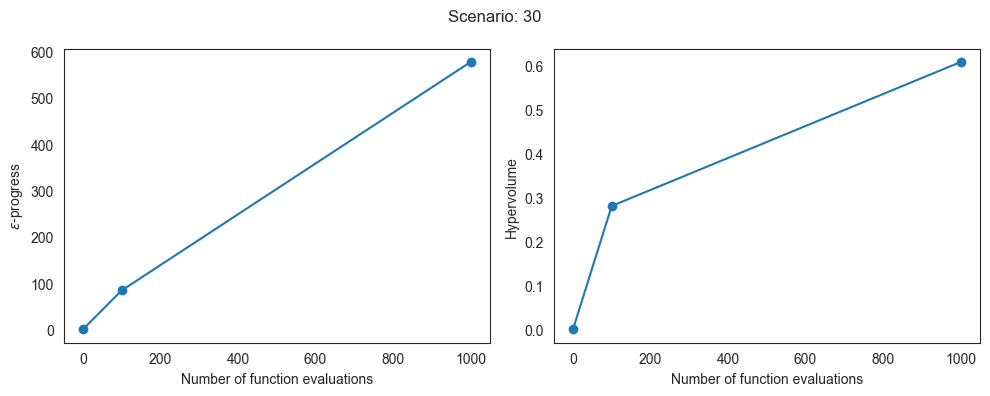


🔁 Running optimization for scenario: 0


[MainProcess/INFO] pool started with 8 workers
100%|██████████████████████████████████████| 1000/1000 [00:43<00:00, 23.22it/s]
[MainProcess/INFO] optimization completed, found 278 solutions
[MainProcess/INFO] terminating pool


✅ Filtered outcomes for scenario 0:
A_5_Total_Costs
A_5_Expected_Number_of_Deaths
RfR_Total_Costs
Expected_Evacuation_Costs
   hypervolume   nfe
0     0.000000     0
1     0.443412   100
2     0.698781  1000


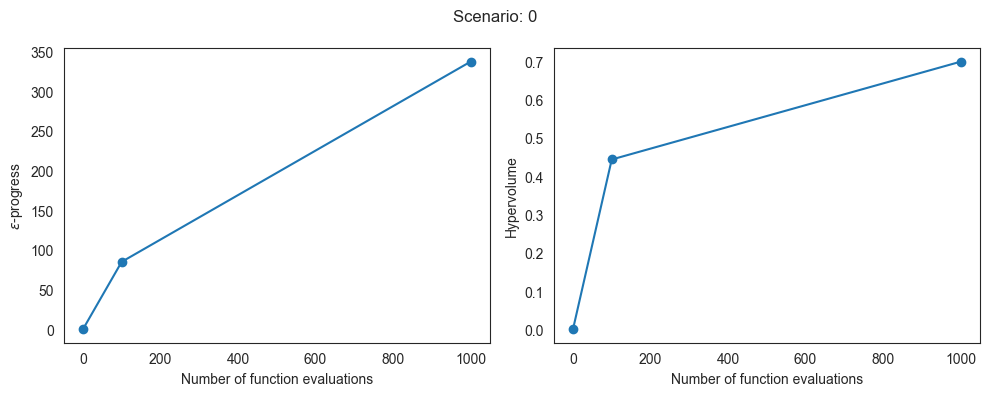

In [26]:
from ema_workbench import ema_logging, Scenario
from problem_formulation import get_model_for_problem_formulation  # ensure this is correct
from ema_workbench.em_framework.optimization import ArchiveLogger, EpsilonProgress, to_problem, epsilon_nondominated, HypervolumeMetric
from ema_workbench import MultiprocessingEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import os


def clean_name(name, prefix="L_"):
    clean = name.replace(" ", "_").replace(".", "_").replace("-", "_")
    if clean[0].isdigit():
        clean = prefix + clean
    return clean

def clean_column_names(df, prefix="L_"):
    df = df.copy()
    df.columns = [clean_name(col, prefix=prefix) for col in df.columns]
    return df

objectives_of_interest = [
    "A.5 Total Costs",
    "A.5_Expected Number of Deaths",
    "RfR Total Costs",
    "Expected Evacuation Costs"
]

cleaned_objectives_of_interest = [clean_name(o, "O_") for o in objectives_of_interest]



if __name__ == "__main__":
    ema_logging.log_to_stderr(ema_logging.INFO)

    for scenario in scenarios:
        print(f"\n🔁 Running optimization for scenario: {scenario.name}")

        model, steps = get_model_for_problem_formulation(3)

        # Reference values
        reference_values = {
            "Bmax": 175,
            "Brate": 1.5,
            "pfail": 0.5,
            "discount rate 0": 3.5,
            "discount rate 1": 3.5,
            "discount rate 2": 3.5,
            "ID flood wave shape": 4,
        }

        scen1 = {}
        for key in model.uncertainties:
            name_split = key.name.split("_")
            key_id = name_split[1] if len(name_split) > 1 else key.name
            scen1[key.name] = reference_values[key_id]

        ref_scenario = Scenario("reference", **scen1)

        # Clean lever and outcome names
        cleaned_lever_names = [clean_name(l.name, "L_") for l in model.levers]
        cleaned_outcome_names = [clean_name(o.name, "O_") for o in model.outcomes]

        # Create archive path per scenario
        archive_path = f"./archives/optimization_{scenario.name}.tar.gz"
        os.makedirs("./archives", exist_ok=True)
        if os.path.exists(archive_path):
            os.remove(archive_path)

        convergence_metrics = [
            ArchiveLogger(
                "./archives",
                cleaned_lever_names,
                cleaned_outcome_names,
                base_filename=f"optimization_{scenario.name}.tar.gz",
            ),
            EpsilonProgress(),
        ]

        # Run optimization
        with MultiprocessingEvaluator(model) as evaluator:
            results, convergence = evaluator.optimize(
                nfe=1000,
                searchover='levers',
                convergence=convergence_metrics,
                epsilons=[0.01] * len(model.outcomes),
                reference=ref_scenario
            )

        # Load archive and clean
        archive_test = ArchiveLogger.load_archives(f"./archives/optimization_{scenario.name}.tar.gz")
        archive_test_clean = {k: clean_column_names(v) for k, v in archive_test.items()}
        reference_set_clean = clean_column_names(results)

        # Filter outcomes
        for lever in model.levers:
            lever.name = clean_name(lever.name, "L_")

        names_to_keep = []
        for o in model.outcomes:
            cleaned = clean_name(o.name, prefix="O_")
            if cleaned in cleaned_objectives_of_interest:
                names_to_keep.append(o.name)

        for name in list(model.outcomes.keys()):
            if name not in names_to_keep:
                del model.outcomes[name]

        for o in model.outcomes:
            o.name = clean_name(o.name, prefix="O_")

        print(f"✅ Filtered outcomes for scenario {scenario.name}:")
        for o in model.outcomes:
            print(o.name)

        problem = to_problem(model, searchover="levers")
        problem._outcome_names = cleaned_objectives_of_interest
        cleaned_lever_names = problem.parameter_names

        reference_set_reduced = reference_set_clean[cleaned_objectives_of_interest + cleaned_lever_names]
        archive_test_reduced = {
            k: v[cleaned_objectives_of_interest + cleaned_lever_names] for k, v in archive_test_clean.items()
        }

        reference_set_final = epsilon_nondominated(
            [reference_set_reduced.iloc[[i]] for i in range(len(reference_set_reduced))],
            [0.05] * len(objectives_of_interest),
            problem
        )

        # Compute hypervolume
        def calculate_convergence_metrics(problem, archives_file, reference_set):
            hv = HypervolumeMetric(reference_set, problem)
            metrics = []
            for nfe, archive in archives_file.items():
                scores = {"hypervolume": hv.calculate(archive), "nfe": nfe}
                metrics.append(scores)
            df = pd.DataFrame.from_dict(metrics)
            df.sort_values(by="nfe", inplace=True, ignore_index=True)
            return df

        metrics = calculate_convergence_metrics(problem, archive_test_reduced, reference_set_final)
        print(metrics)


        # Plot
        epsilon_nfe = convergence["nfe"]
        epsilon_values = convergence["epsilon_progress"]
        hv_nfe = metrics["nfe"]
        hv_values = metrics["hypervolume"]

        fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True, figsize=(10, 4))
        ax1.plot(epsilon_nfe, epsilon_values, marker='o')
        ax1.set_ylabel('$\\epsilon$-progress')
        ax2.plot(hv_nfe, hv_values, marker='o')
        ax2.set_ylabel('Hypervolume')
        ax1.set_xlabel('Number of function evaluations')
        ax2.set_xlabel('Number of function evaluations')
        fig.suptitle(f"Scenario: {scenario.name}")
        plt.tight_layout()
        plt.show()
